# Team Alpha - DataHer Datathon

This project is towards the DataHer Hackton where my Team is looking into Education and Economic Inclusion Challenge.
We will sue the women in stem data (source kaggle : https://www.kaggle.com/datasets/bismasajjad/womens-representation-in-global-stem-education), US Jobs data (Source Kaggle) and Technology data from Worldbank.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

To start with, we will be using the women in stem data which shows the Gender Gap index. It will show us the Female enrollment and compare it with their graduation rate in different STEM field by Year and Country to understand the Gender Gap Index. This will now be compared with the World bank data to compare those countries and year with the internet usage based on what the outcome is

In [7]:
df = pd.read_csv("women_in_stem.csv")

In [8]:
df

,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74
...,...,...,...,...,...,...
495,Australia,2016,37.2,50.1,Biology,0.91
496,India,2010,59.1,61.2,Engineering,0.66
497,Germany,2010,34.7,34.2,Engineering,0.92
498,Australia,2011,61.2,39.9,Mathematics,0.85


Now load the world bank technology data 

In [10]:
# 2. Load the World Bank Internet-usage data
# (you’ll need to download the CSV for the indicator IT.NET.USER.ZS via World Bank DataBank)
tech = pd.read_csv("technology.csv")


Now we have the two datasets. Phew. Let us start diving into what to do 

In [11]:
print(df.dtypes)

Country                        object
Year                            int64
Female Enrollment (%)         float64
Female Graduation Rate (%)    float64
STEM Fields                    object
Gender Gap Index              float64
dtype: object


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     500 non-null    object 
 1   Year                        500 non-null    int64  
 2   Female Enrollment (%)       500 non-null    float64
 3   Female Graduation Rate (%)  500 non-null    float64
 4   STEM Fields                 500 non-null    object 
 5   Gender Gap Index            500 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 23.6+ KB


In [13]:
df.shape

(500, 6)

In [14]:
df.isna().sum()

Country                       0
Year                          0
Female Enrollment (%)         0
Female Graduation Rate (%)    0
STEM Fields                   0
Gender Gap Index              0
dtype: int64

In [15]:
df.describe()

,Year,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
count,500.000000,500.000000,500.000000,500.000000
mean,2011.418000,43.939800,36.715200,0.745980
std,7.187112,14.316864,15.964231,0.138183
min,2000.000000,20.100000,10.100000,0.500000
25%,2005.000000,31.575000,23.150000,0.630000
50%,2011.000000,43.500000,35.900000,0.750000
75%,2018.000000,56.500000,50.425000,0.860000
max,2023.000000,69.500000,64.900000,1.000000


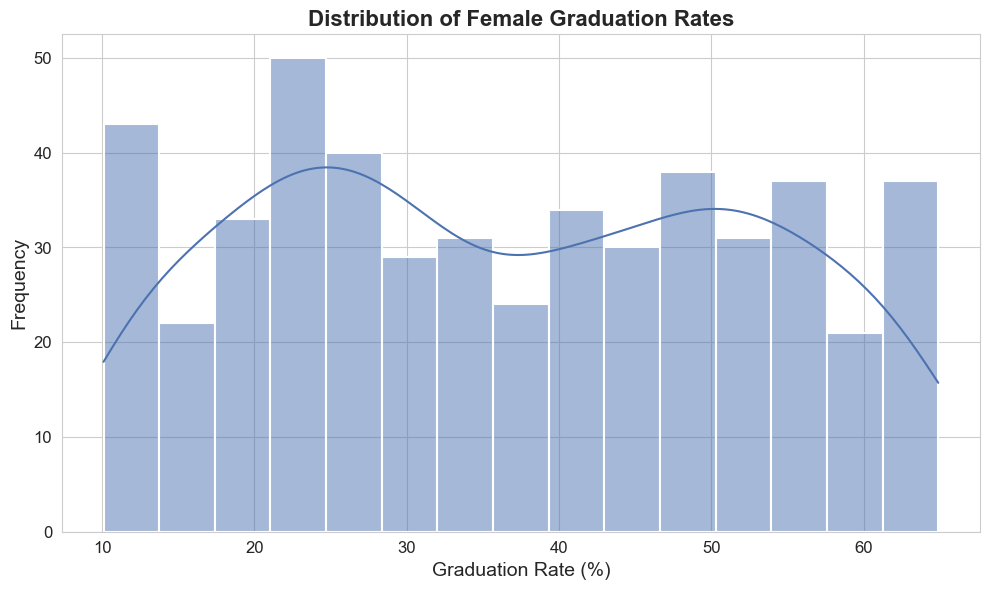

In [17]:
plt.figure(figsize=(10, 6))

sns.set_style("whitegrid")  # cleaner background
sns.set_palette("viridis")  # modern color palette

sns.histplot(
    df['Female Graduation Rate (%)'],
    kde=True,
    bins=15,
    color="#4C72B0",
    edgecolor="white",
    linewidth=1.5
)

plt.title('Distribution of Female Graduation Rates', fontsize=16, weight='bold')
plt.xlabel('Graduation Rate (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()  # removes extra padding
plt.show()


In [23]:
# Count number of records per Country–Year–STEM field
df_group = (
    df
    .groupby(['Country', 'Year', 'STEM Fields'], as_index=False)
    .size()
    .rename(columns={'size': 'Count'})
)

# Keep only groups that appear 2+ times
df_group = df_group[df_group['Count'] >= 2]


#pd.set_option('display.max_rows', None)

df_group

,Country,Year,STEM Fields,Count
1,Australia,2000,Computer Science,3
3,Australia,2000,Mathematics,2
6,Australia,2001,Mathematics,3
7,Australia,2002,Mathematics,2
8,Australia,2003,Computer Science,3
10,Australia,2004,Biology,2
12,Australia,2005,Biology,2
16,Australia,2006,Mathematics,2
18,Australia,2007,Computer Science,2
20,Australia,2008,Mathematics,2


This is showing more rows that what can be ploted so will use the average 

In [24]:
dfmean=df.groupby(['Country','Year','STEM Fields'], as_index=False).agg({'Female Enrollment (%)':'mean','Female Graduation Rate (%)':'mean','Gender Gap Index':'mean'})

C:\Users\olaba\AppData\Local\Temp\ipykernel_28116\3227068185.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


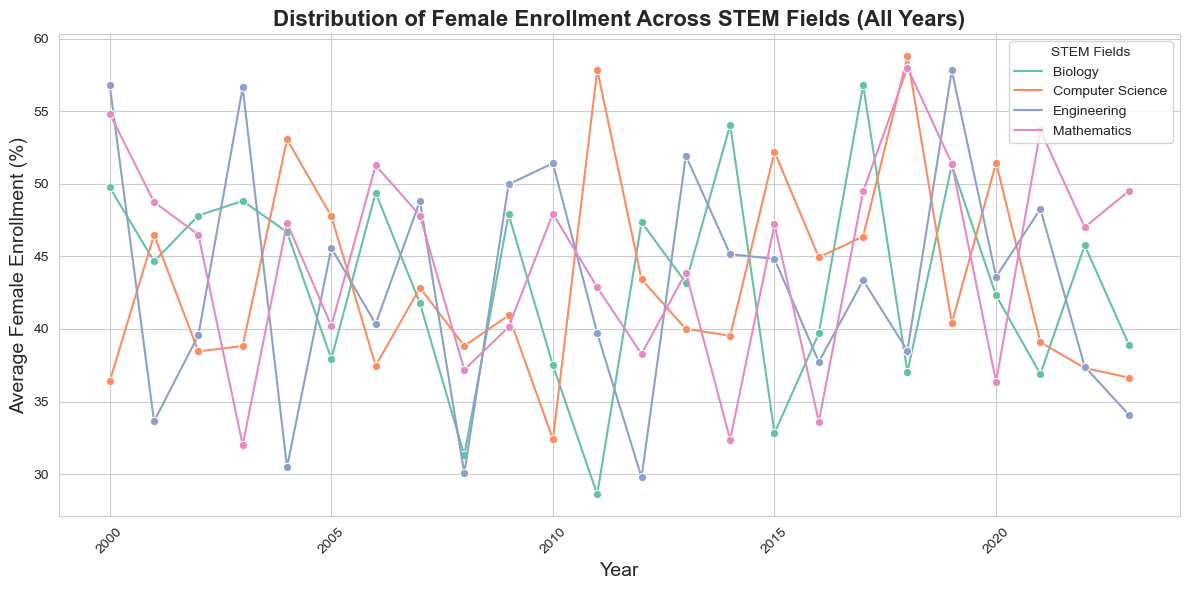

In [31]:

# Aggregate your data if not already
dfmean = df.groupby(['Country','Year','STEM Fields'], as_index=False).agg({
    'Female Enrollment (%)':'mean',
    'Female Graduation Rate (%)':'mean',
    'Gender Gap Index':'mean'
})

# Line plot: Average Female Enrollment by STEM Field over the years
plt.figure(figsize=(12,6))
sns.lineplot(
    data=dfmean,
    x='Year',
    y='Female Enrollment (%)',
    hue='STEM Fields',
    ci=None,
    marker='o',
    palette='Set2'
)

plt.title('Distribution of Female Enrollment Across STEM Fields (All Years)', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Female Enrollment (%)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='STEM Fields')
plt.tight_layout()
plt.show()


C:\Users\olaba\AppData\Local\Temp\ipykernel_28116\16319440.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


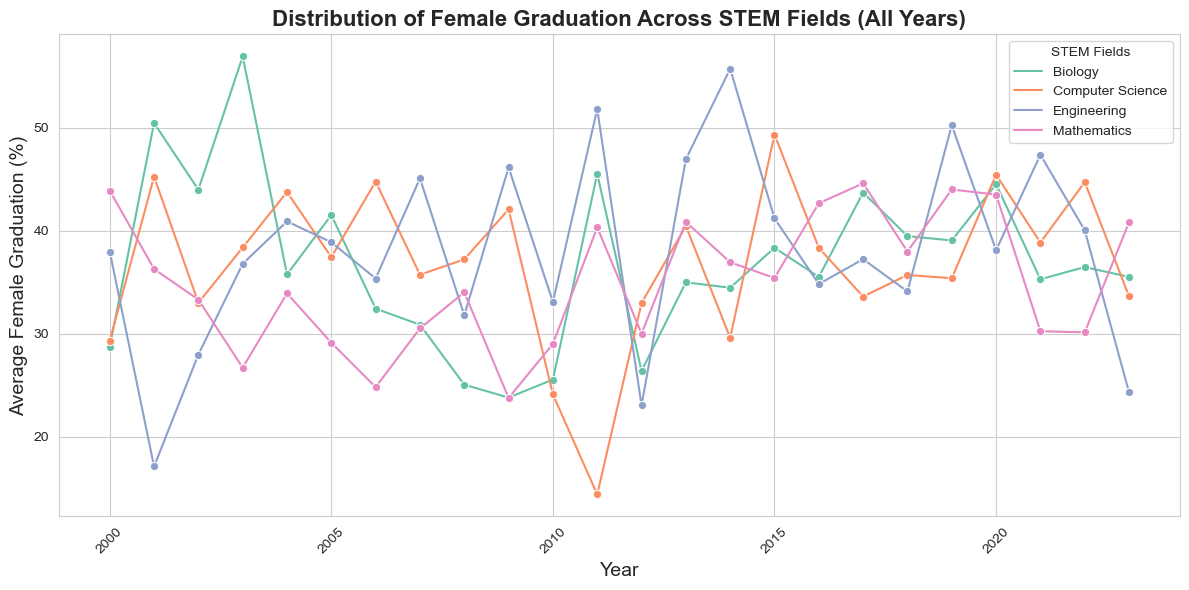

In [33]:

# Aggregate your data if not already
dfmean = df.groupby(['Country','Year','STEM Fields'], as_index=False).agg({
    'Female Enrollment (%)':'mean',
    'Female Graduation Rate (%)':'mean',
    'Gender Gap Index':'mean'
})

# Line plot: Average Female Enrollment by STEM Field over the years
plt.figure(figsize=(12,6))
sns.lineplot(
    data=dfmean,
    x='Year',
    y='Female Graduation Rate (%)',
    hue='STEM Fields',
    ci=None,
    marker='o',
    palette='Set2'
)

plt.title('Distribution of Female Graduation Across STEM Fields (All Years)', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Female Graduation (%)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='STEM Fields')
plt.tight_layout()
plt.show()

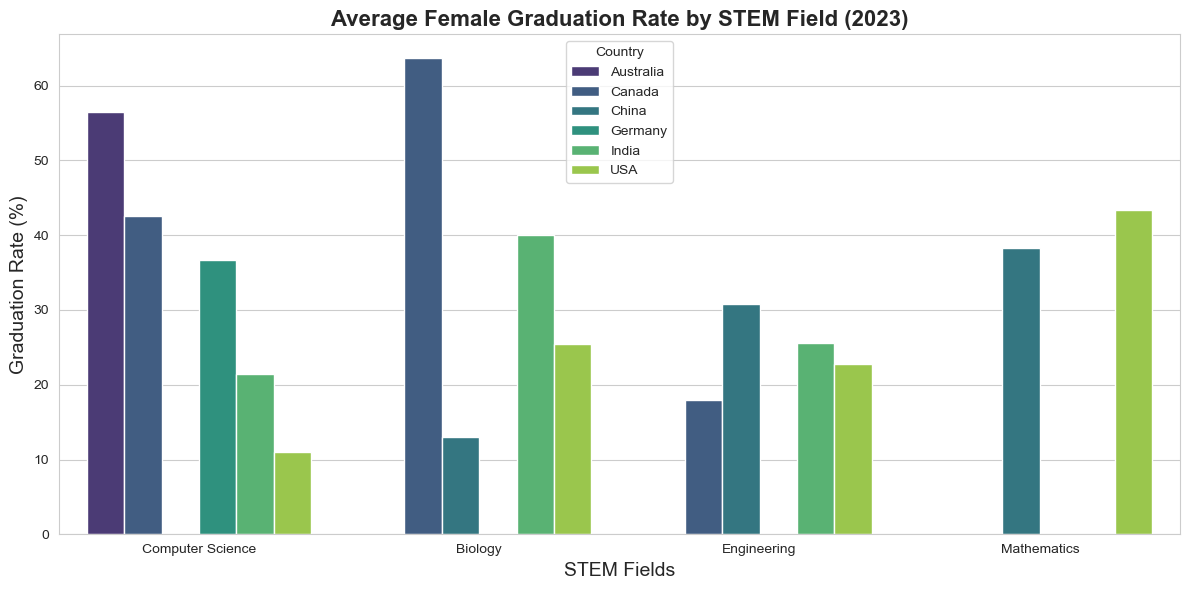

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose you want to focus on a specific year, e.g., 2023
df_2023 = dfmean[dfmean['Year'] == 2023]

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_2023,
    x='STEM Fields',
    y='Female Graduation Rate (%)',
    hue='Country',  # shows comparison across countries
    palette='viridis'
)

plt.title('Average Female Graduation Rate by STEM Field (2023)', fontsize=16, weight='bold')
plt.xlabel('STEM Fields', fontsize=14)
plt.ylabel('Graduation Rate (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Country')
plt.tight_layout()
plt.show()


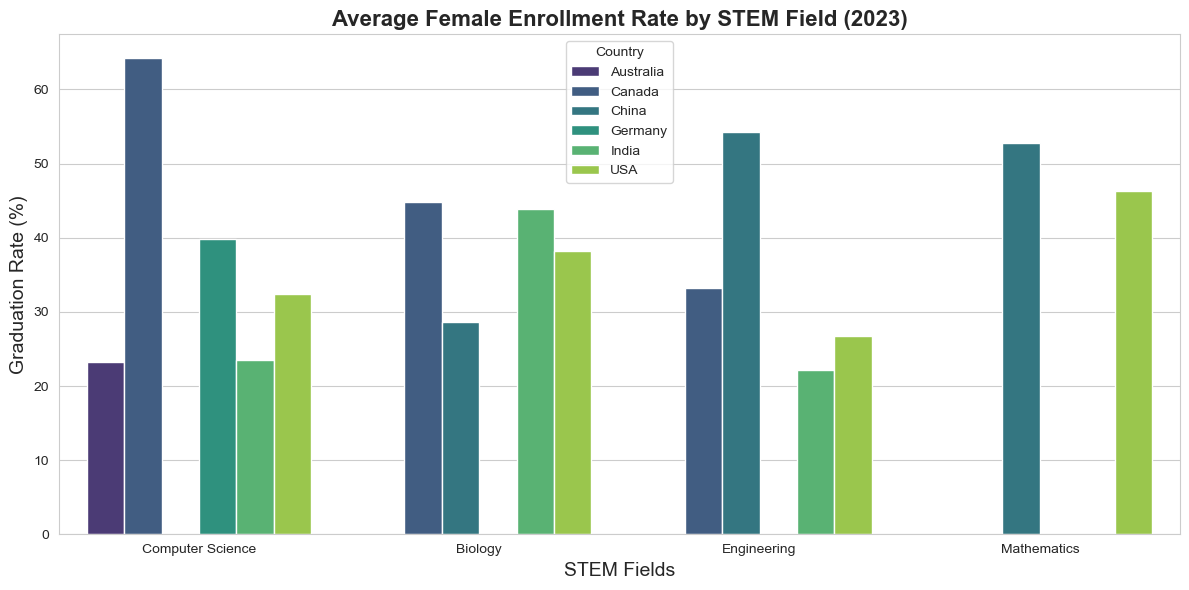

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose you want to focus on a specific year, e.g., 2023
df_2023 = dfmean[dfmean['Year'] == 2023]

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_2023,
    x='STEM Fields',
    y='Female Enrollment (%)',
    hue='Country',  # shows comparison across countries
    palette='viridis'
)

plt.title('Average Female Enrollment Rate by STEM Field (2023)', fontsize=16, weight='bold')
plt.xlabel('STEM Fields', fontsize=14)
plt.ylabel('Graduation Rate (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Country')
plt.tight_layout()
plt.show()


In [25]:
dfmean

,Country,Year,STEM Fields,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
0,Australia,2000,Biology,68.200000,62.500000,0.990000
1,Australia,2000,Computer Science,34.400000,28.533333,0.843333
2,Australia,2000,Engineering,68.000000,31.300000,0.510000
3,Australia,2000,Mathematics,52.900000,35.350000,0.870000
4,Australia,2001,Computer Science,51.100000,50.700000,0.630000
5,Australia,2001,Engineering,40.000000,11.600000,0.940000
6,Australia,2001,Mathematics,28.966667,46.066667,0.716667
7,Australia,2002,Mathematics,42.900000,44.100000,0.775000
8,Australia,2003,Computer Science,33.966667,39.266667,0.630000
9,Australia,2003,Engineering,66.900000,33.700000,0.680000


([0, 1, 2, 3],
 [Text(0, 0, 'Biology'),
  Text(1, 0, 'Computer Science'),
  Text(2, 0, 'Engineering'),
  Text(3, 0, 'Mathematics')])

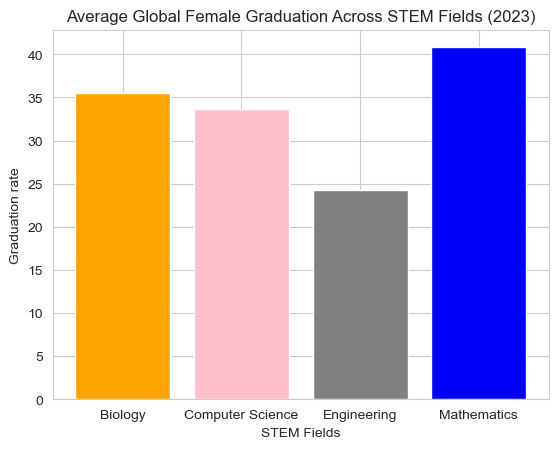

In [27]:
df_copy=dfmean[dfmean["Year"]==2023]
df_copy=df_copy.drop(columns=["Female Enrollment (%)", "Gender Gap Index", "Country", "Year"])
df_copy= df_copy.groupby('STEM Fields')['Female Graduation Rate (%)'].agg({'mean'})

stemfields=df_copy.index.tolist()
enroll=df_copy['mean']

colors = ['orange', 'pink', 'grey', 'blue']

graph_one = plt.bar(stemfields, enroll, color=colors) #Plots graph

plt.title('Average Global Female Graduation Across STEM Fields (2023)')
plt.xlabel('STEM Fields')
plt.ylabel('Graduation rate')
plt.xticks(rotation=0) #Add-ons to the graph

#In 2023, mathematics had the highest female enrollment percentage, reaching nearly 50 percent. 
#Meanwhile, engineering trailed behind at the end with around 35 percent enrollment.

In [35]:
max_df= (dfmean.sort_values(by='Female Enrollment (%)')).tail(5)
#Sorting the dataset to find the highest enrollment rates
max_df

,Country,Year,STEM Fields,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
315,USA,2013,Mathematics,68.4,32.8,0.75
168,China,2022,Biology,68.5,37.9,0.52
153,China,2016,Computer Science,68.7,34.7,0.51
90,Canada,2013,Engineering,69.1,32.9,0.54
83,Canada,2010,Mathematics,69.4,28.2,0.89


In [37]:
max_grad= (dfmean.sort_values(by='Female Graduation Rate (%)')).tail(5)
#Sorting the dataset to find the highest enrollment rates
max_grad

,Country,Year,STEM Fields,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
216,Germany,2019,Computer Science,21.5,64.1,0.77
295,USA,2004,Computer Science,47.5,64.1,0.73
164,China,2020,Computer Science,36.7,64.3,0.96
179,Germany,2003,Biology,43.4,64.7,0.78
150,China,2015,Biology,42.9,64.8,0.80


using the most recent year, check which country to check for more insoght in data

In [42]:
x = ["Female Enrollment (%)", "Female Graduation Rate (%)"]
newcol=dfmean.drop(columns=x)
newcol1=newcol[newcol["Year"]==2021]
newcol1.sort_values("Gender Gap Index",ascending=True)#countries' gender gap index of four STEM fields in 2021
plotdf=newcol1.pivot(index="Country",columns="STEM Fields",values="Gender Gap Index").reset_index(drop=False)
#Draw a grouped bar chart in order to analyze the relationships between three variables

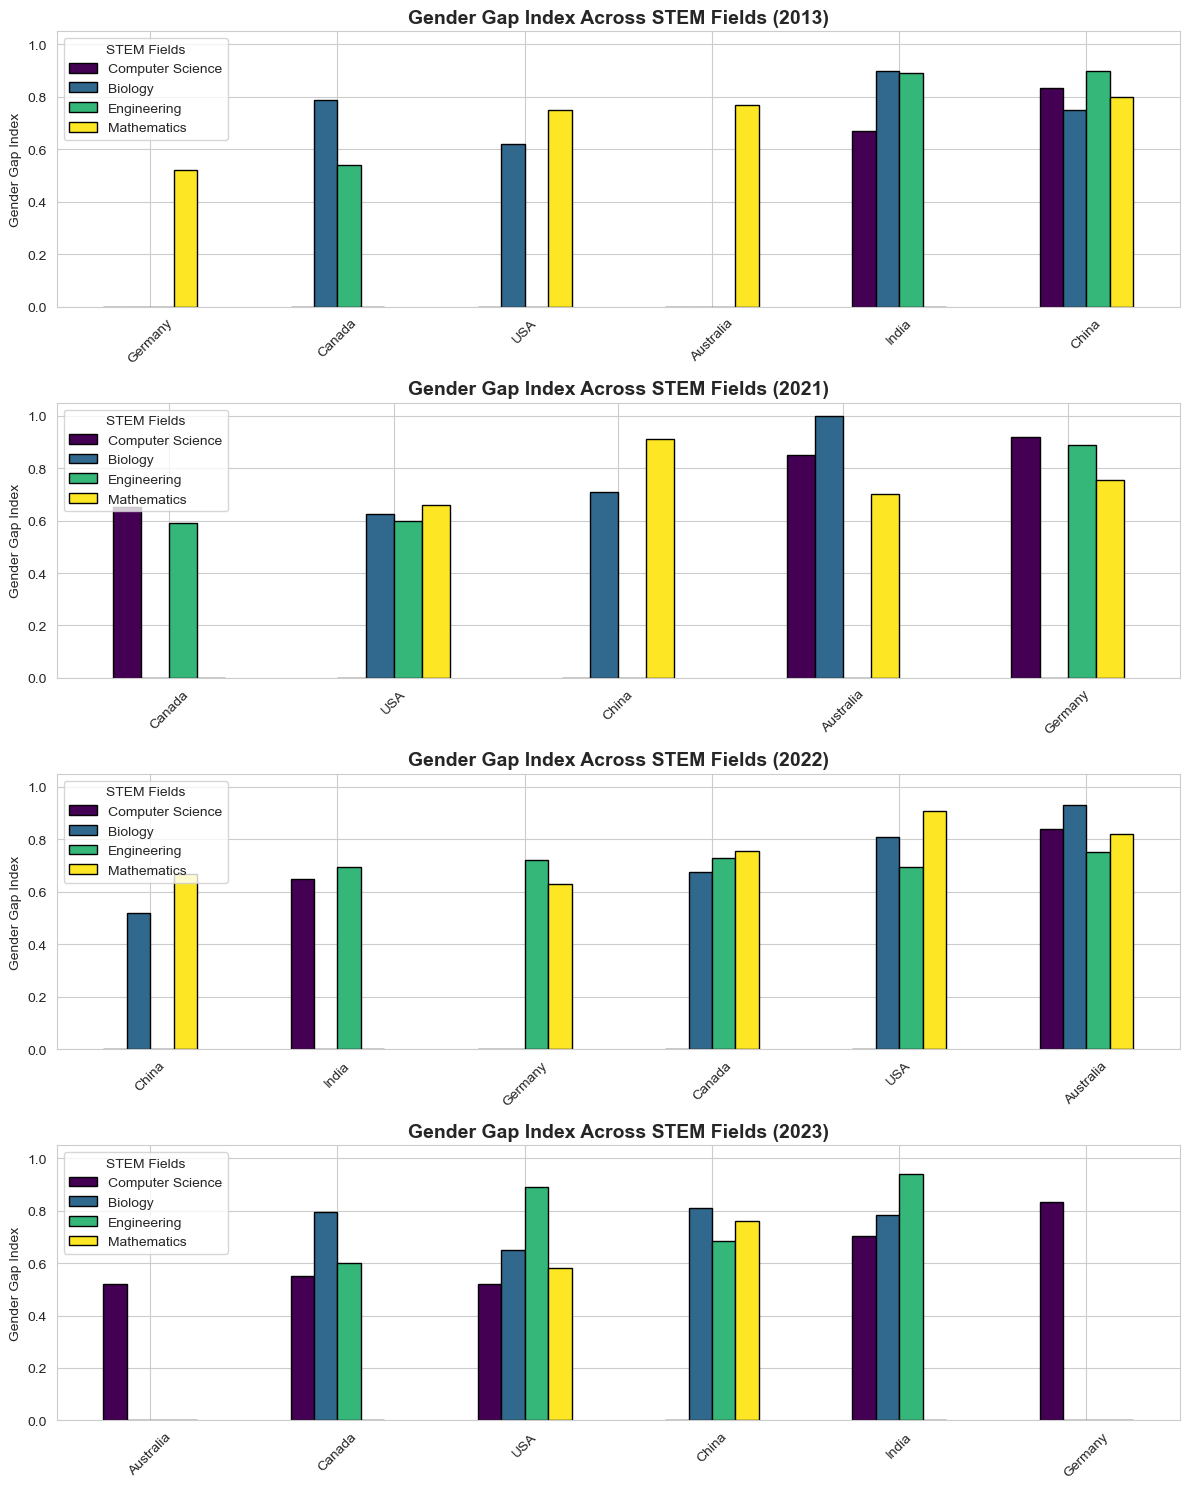

In [47]:


# STEM fields to plot
stem_fields = ["Computer Science", "Biology", "Engineering", "Mathematics"]
years = [2013, 2021, 2022, 2023]

# Set up subplots
fig, axes = plt.subplots(len(years), 1, figsize=(12, 15), sharey=True)

for i, year in enumerate(years):
    df_year = newcol[newcol["Year"] == year].copy()
    
    # Pivot to have STEM fields as columns
    plotdf = df_year.pivot(index="Country", columns="STEM Fields", values="Gender Gap Index").reset_index()
    
    # Sort countries by average Gender Gap Index across STEM fields
    plotdf['mean_gap'] = plotdf[stem_fields].mean(axis=1)
    plotdf = plotdf.sort_values('mean_gap', ascending=True).drop(columns='mean_gap')
    
    # Plot
    plotdf.plot.bar(
        x="Country",
        y=stem_fields,
        ax=axes[i],
        colormap='viridis',
        rot=45,
        edgecolor='black'
    )
    
    axes[i].set_title(f'Gender Gap Index Across STEM Fields ({year})', fontsize=14, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Gender Gap Index')

plt.tight_layout()
plt.show()


Australia 2022 and china 2021 and usa 2024, had the 4 grops complredted in data

we will go to investigate austrasllia

relationship between gender gap index and female enrollment in each field in 

In [50]:
china_df = dfmean[dfmean["Country"]=="China"].reset_index()
china_df = china_df.drop(["Female Graduation Rate (%)","Country"], axis = 1)
china_df = china_df.drop(["index","Year"], axis = 1)


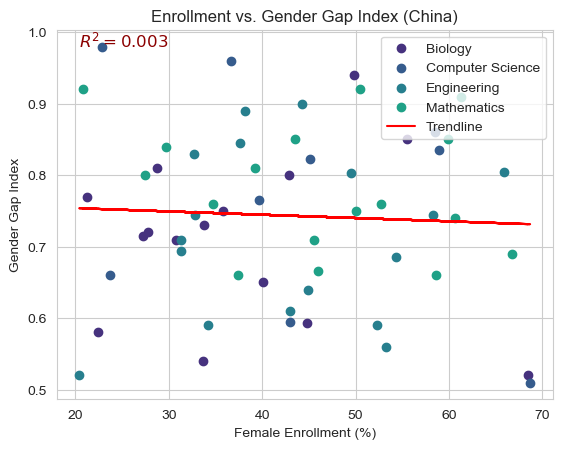

In [51]:
#drawing the subplots using groupby
fig, ax = plt.subplots()

for field,group in china_df.groupby('STEM Fields'):
    ax.scatter(group['Female Enrollment (%)'],group['Gender Gap Index'],label = field)
    
ax.legend(title = "STEM Fields")

x = china_df['Female Enrollment (%)']
y = china_df['Gender Gap Index']

#linear regression line
slope, intercept = np.polyfit(x, y, 1)
trendline = [slope * xi + intercept for xi in x]
plt.plot(x, trendline, color='red', label='Trendline')

#calculate R^2
y_pred = np.array(trendline)
y_actual = np.array(y)
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
plt.text(min(x), max(y), f"$R^2 = {r_squared:.3f}$", fontsize=12, color='darkred')

plt.xlabel("Female Enrollment (%)")
plt.ylabel("Gender Gap Index")
plt.title("Enrollment vs. Gender Gap Index (China)")
plt.legend()

plt.show()

In [54]:
aus_df = dfmean[dfmean["Country"]=="Australia"].reset_index()
aus_df = aus_df.drop(["Female Graduation Rate (%)","Country"], axis = 1)
aus_df = aus_df.drop(["index","Year"], axis = 1)


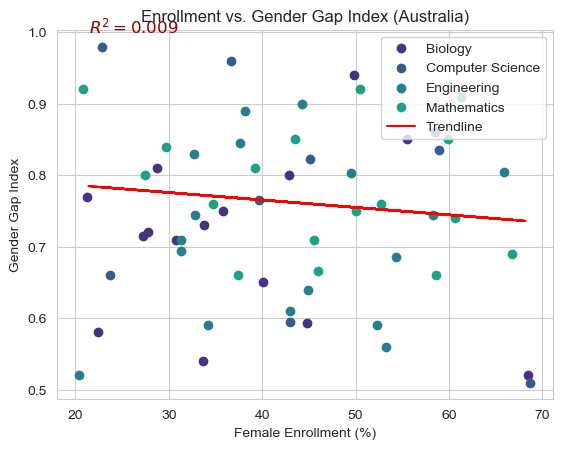

In [55]:
#drawing the subplots using groupby
fig, ax = plt.subplots()

for field,group in china_df.groupby('STEM Fields'):
    ax.scatter(group['Female Enrollment (%)'],group['Gender Gap Index'],label = field)
    
ax.legend(title = "STEM Fields")

x = aus_df['Female Enrollment (%)']
y = aus_df['Gender Gap Index']

#linear regression line
slope, intercept = np.polyfit(x, y, 1)
trendline = [slope * xi + intercept for xi in x]
plt.plot(x, trendline, color='red', label='Trendline')

#calculate R^2
y_pred = np.array(trendline)
y_actual = np.array(y)
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
plt.text(min(x), max(y), f"$R^2 = {r_squared:.3f}$", fontsize=12, color='darkred')

plt.xlabel("Female Enrollment (%)")
plt.ylabel("Gender Gap Index")
plt.title("Enrollment vs. Gender Gap Index (Australia)")
plt.legend()

plt.show()

In [56]:
usa_df = dfmean[dfmean["Country"]=="Australia"].reset_index()
usa_df = usa_df.drop(["Female Graduation Rate (%)","Country"], axis = 1)
usa_df = usa_df.drop(["index","Year"], axis = 1)

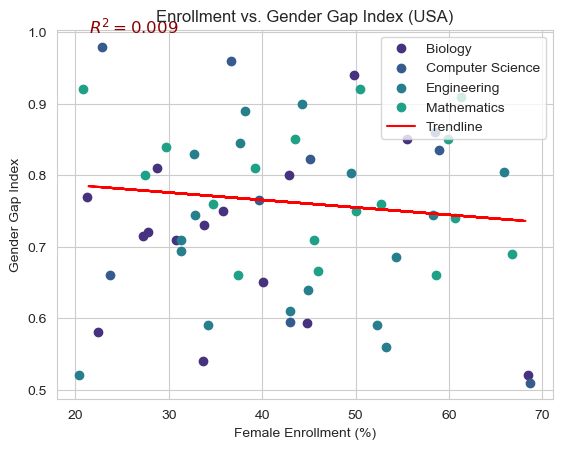

In [57]:
#drawing the subplots using groupby
fig, ax = plt.subplots()

for field,group in china_df.groupby('STEM Fields'):
    ax.scatter(group['Female Enrollment (%)'],group['Gender Gap Index'],label = field)
    
ax.legend(title = "STEM Fields")

x = usa_df['Female Enrollment (%)']
y = usa_df['Gender Gap Index']

#linear regression line
slope, intercept = np.polyfit(x, y, 1)
trendline = [slope * xi + intercept for xi in x]
plt.plot(x, trendline, color='red', label='Trendline')

#calculate R^2
y_pred = np.array(trendline)
y_actual = np.array(y)
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
plt.text(min(x), max(y), f"$R^2 = {r_squared:.3f}$", fontsize=12, color='darkred')

plt.xlabel("Female Enrollment (%)")
plt.ylabel("Gender Gap Index")
plt.title("Enrollment vs. Gender Gap Index (USA)")
plt.legend()

plt.show()

Correlation between Enrollment and Graduation: 0.02


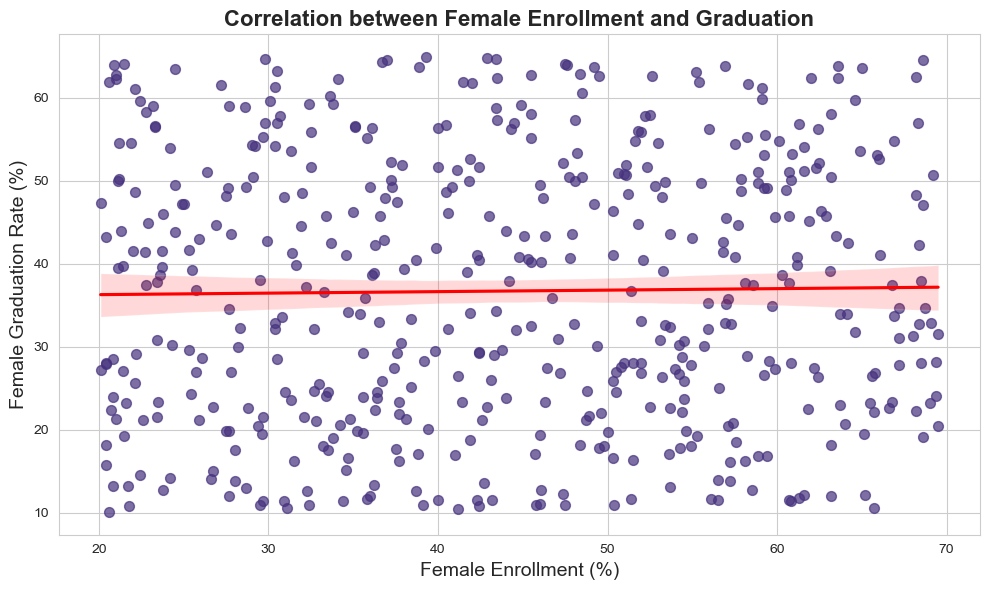

In [58]:


# Calculate correlation
corr = df['Female Enrollment (%)'].corr(df['Female Graduation Rate (%)'])
print(f"Correlation between Enrollment and Graduation: {corr:.2f}")

# Scatter plot with regression line
plt.figure(figsize=(10,6))
sns.regplot(
    x='Female Enrollment (%)',
    y='Female Graduation Rate (%)',
    data=df,
    scatter_kws={'s':50, 'alpha':0.7},
    line_kws={'color':'red'}
)

plt.title('Correlation between Female Enrollment and Graduation', fontsize=16, weight='bold')
plt.xlabel('Female Enrollment (%)', fontsize=14)
plt.ylabel('Female Graduation Rate (%)', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\olaba\AppData\Local\Temp\ipykernel_28116\126726565.py:41: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


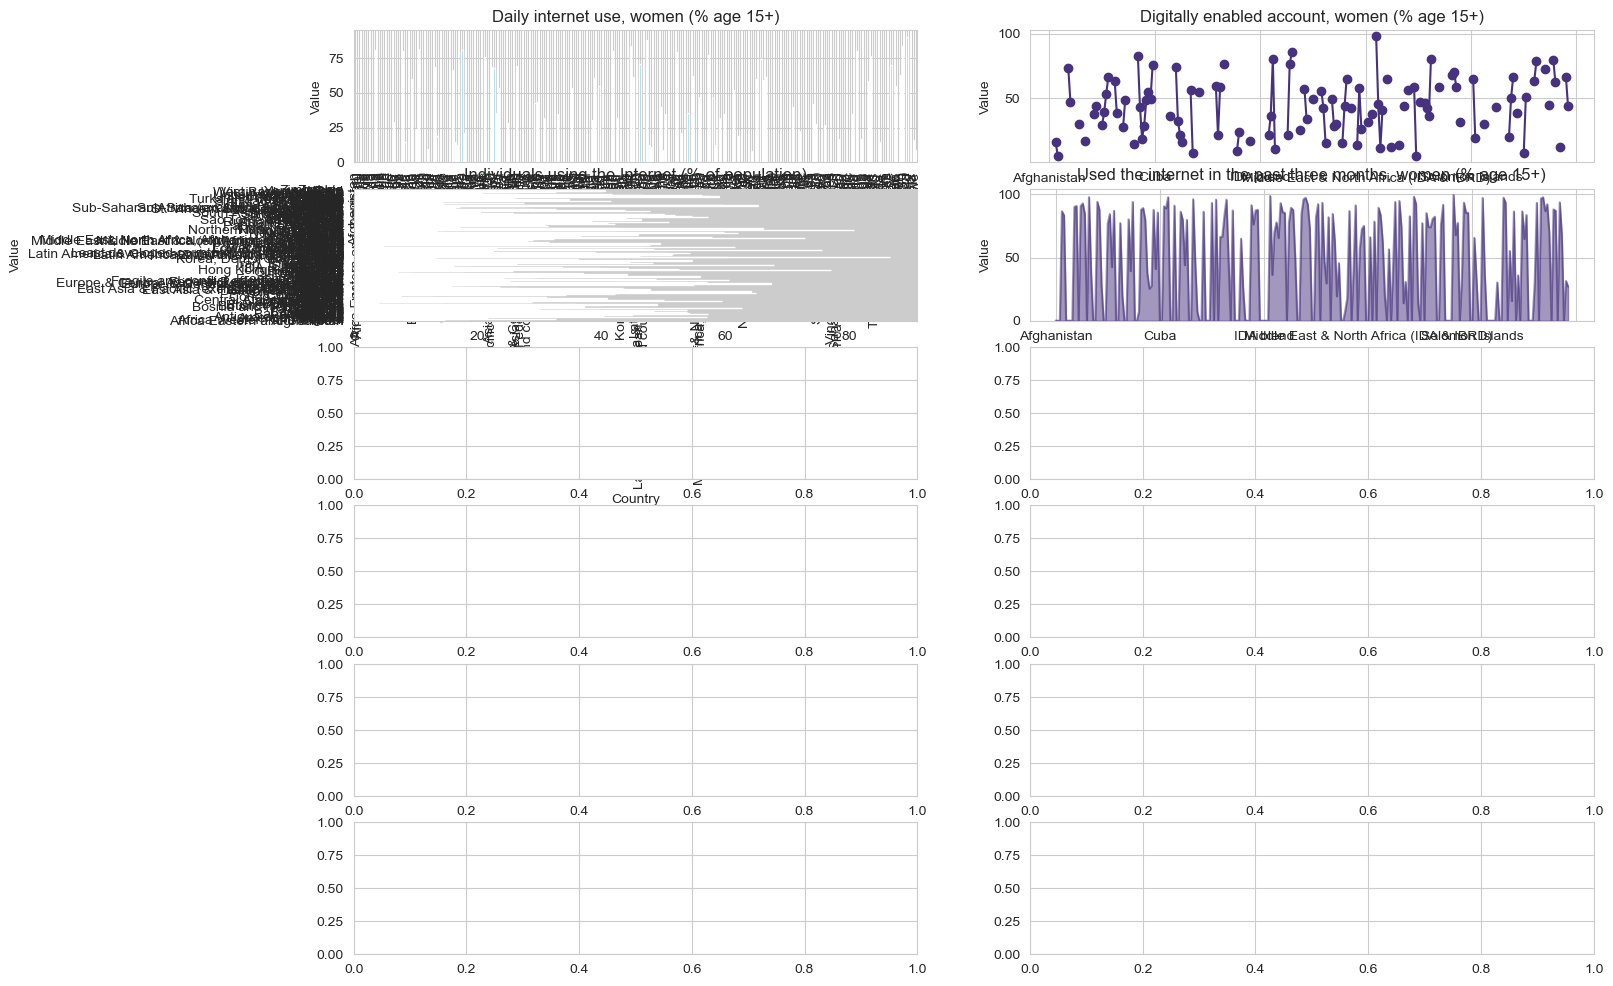

In [65]:


# Select ICT-related indicators
ict_indicators = [
    "Individuals using the Internet (% of population)",
    "Used the internet in the past three months, women (% age 15+)",
    "Daily internet use, women (% age 15+)",
    "Digitally enabled account, women (% age 15+)"

]
df_ict = tech[tech["Indicator Name"].isin(ict_indicators)]

# Pivot for plotting
ict_pivot = df_ict.pivot_table(
    index="Country Name",
    columns="Indicator Name",
    values="Value",
    aggfunc="mean"
).reset_index()

# Set index for easier plotting
ict_pivot.set_index("Country Name", inplace=True)

# Plot different chart types
fig, axes = plt.subplots(6, 2, figsize=(16, 12))
axes = axes.flatten()

chart_types = ['bar', 'line', 'barh', 'area', 'bar', 'line']

for i, col in enumerate(ict_pivot.columns):
    if chart_types[i] == 'bar':
        ict_pivot[col].plot(kind='bar', ax=axes[i], color='skyblue', title=col)
    elif chart_types[i] == 'line':
        ict_pivot[col].plot(kind='line', ax=axes[i], marker='o', title=col)
    elif chart_types[i] == 'barh':
        ict_pivot[col].plot(kind='barh', ax=axes[i], color='orange', title=col)
    elif chart_types[i] == 'area':
        ict_pivot[col].plot(kind='area', ax=axes[i], alpha=0.5, title=col)

    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('Country')

plt.tight_layout()
plt.show()



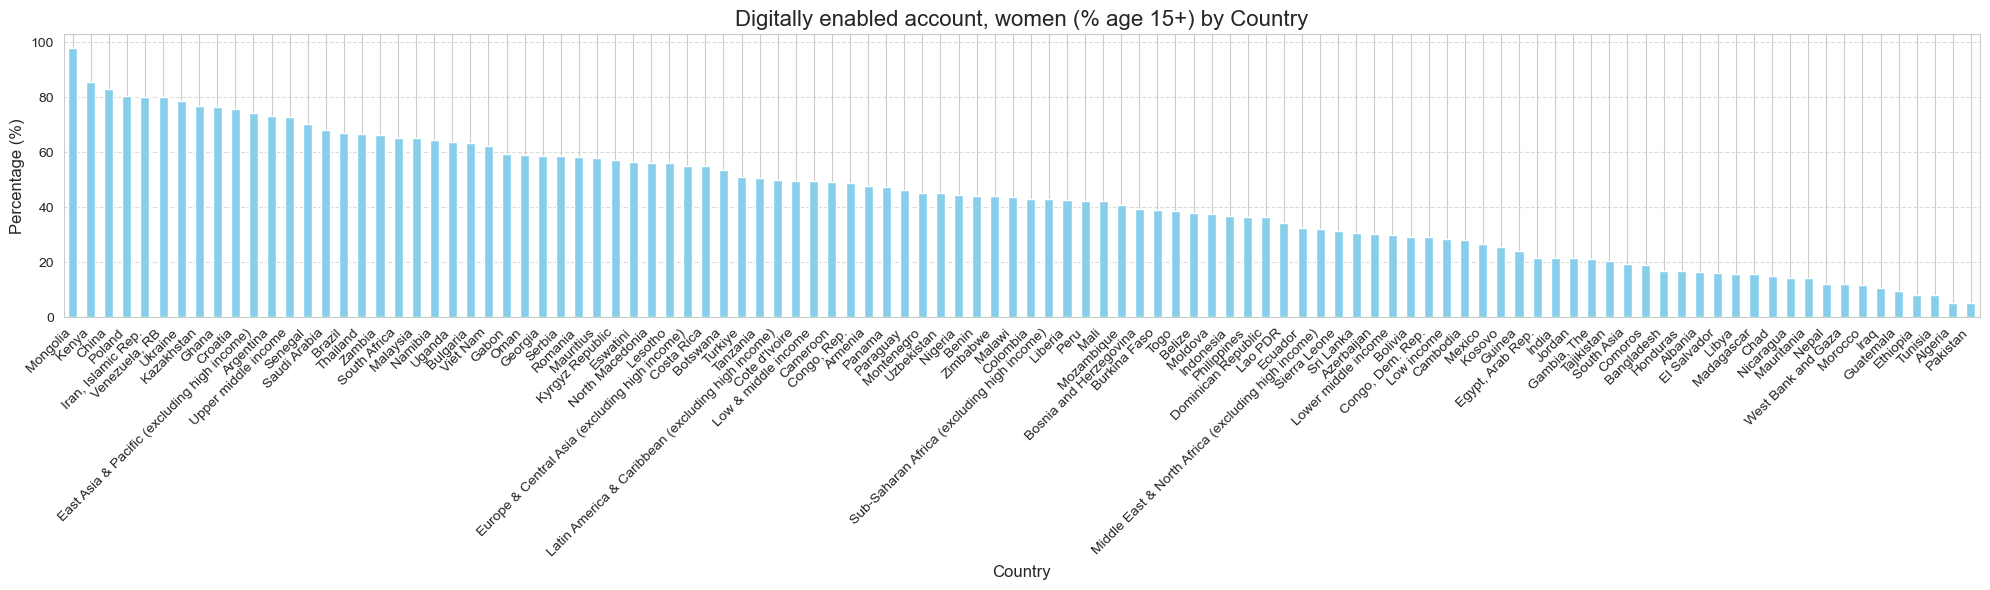

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataset is loaded as 'tech'
# Filter for a single indicator
ict_indicator = "Digitally enabled account, women (% age 15+)"
df_ict = tech[tech["Indicator Name"] == ict_indicator]

# Pivot to have countries as index
ict_pivot = df_ict.pivot_table(
    index="Country Name",
    values="Value",
    aggfunc="mean"
).sort_values(by="Value", ascending=False)

# Plot bar chart
plt.figure(figsize=(20, 6))
ict_pivot['Value'].plot(kind='bar', color='skyblue')
plt.title(f'{ict_indicator} by Country', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




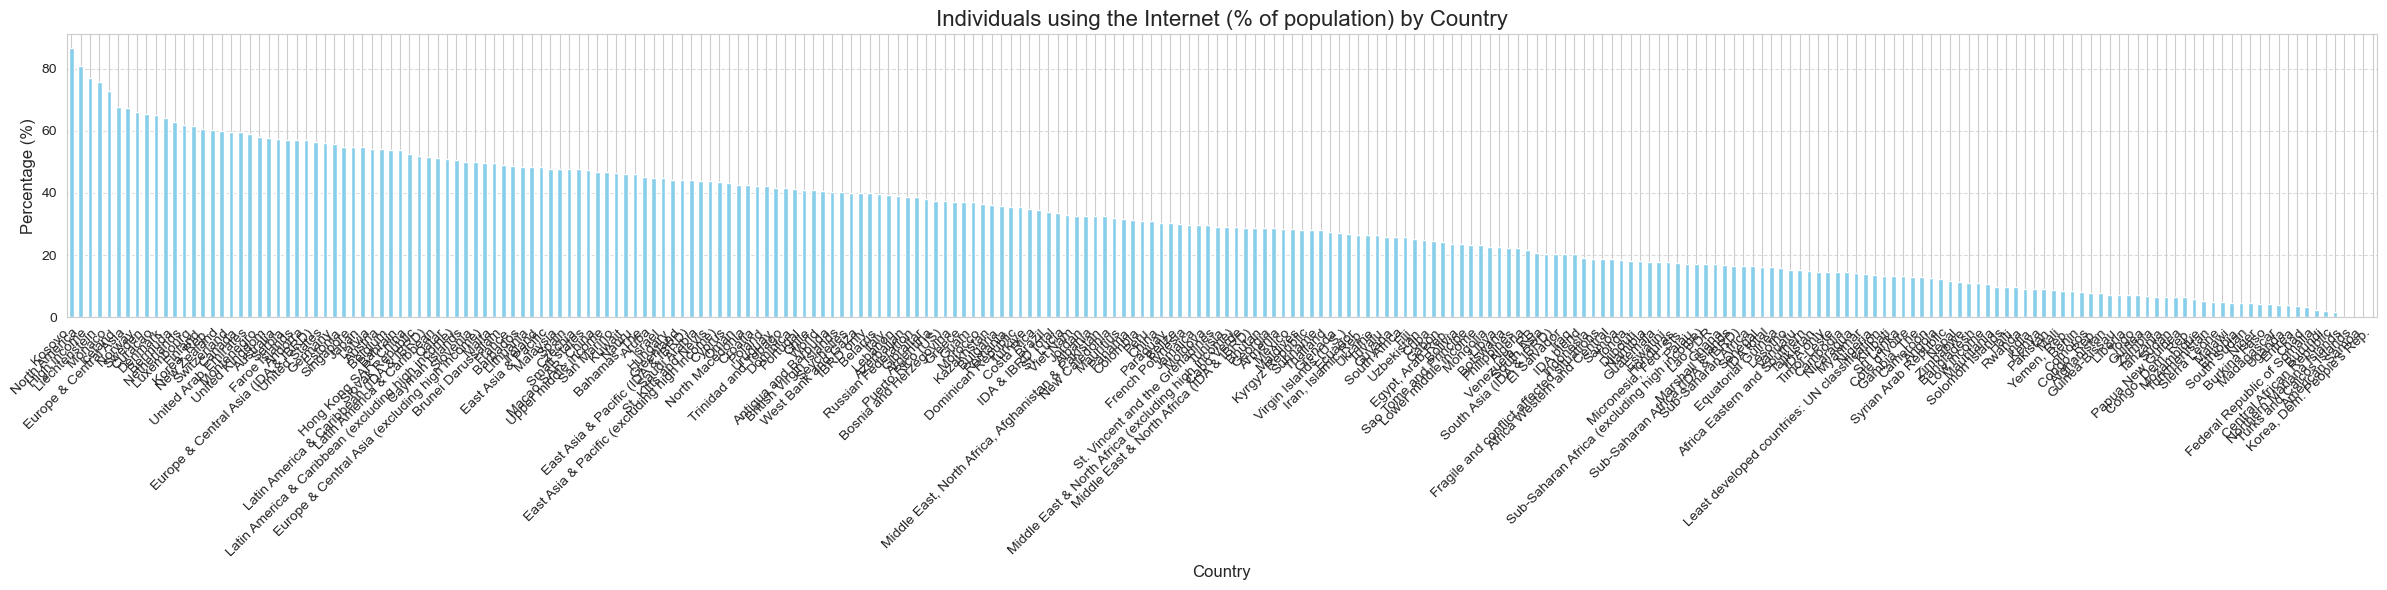

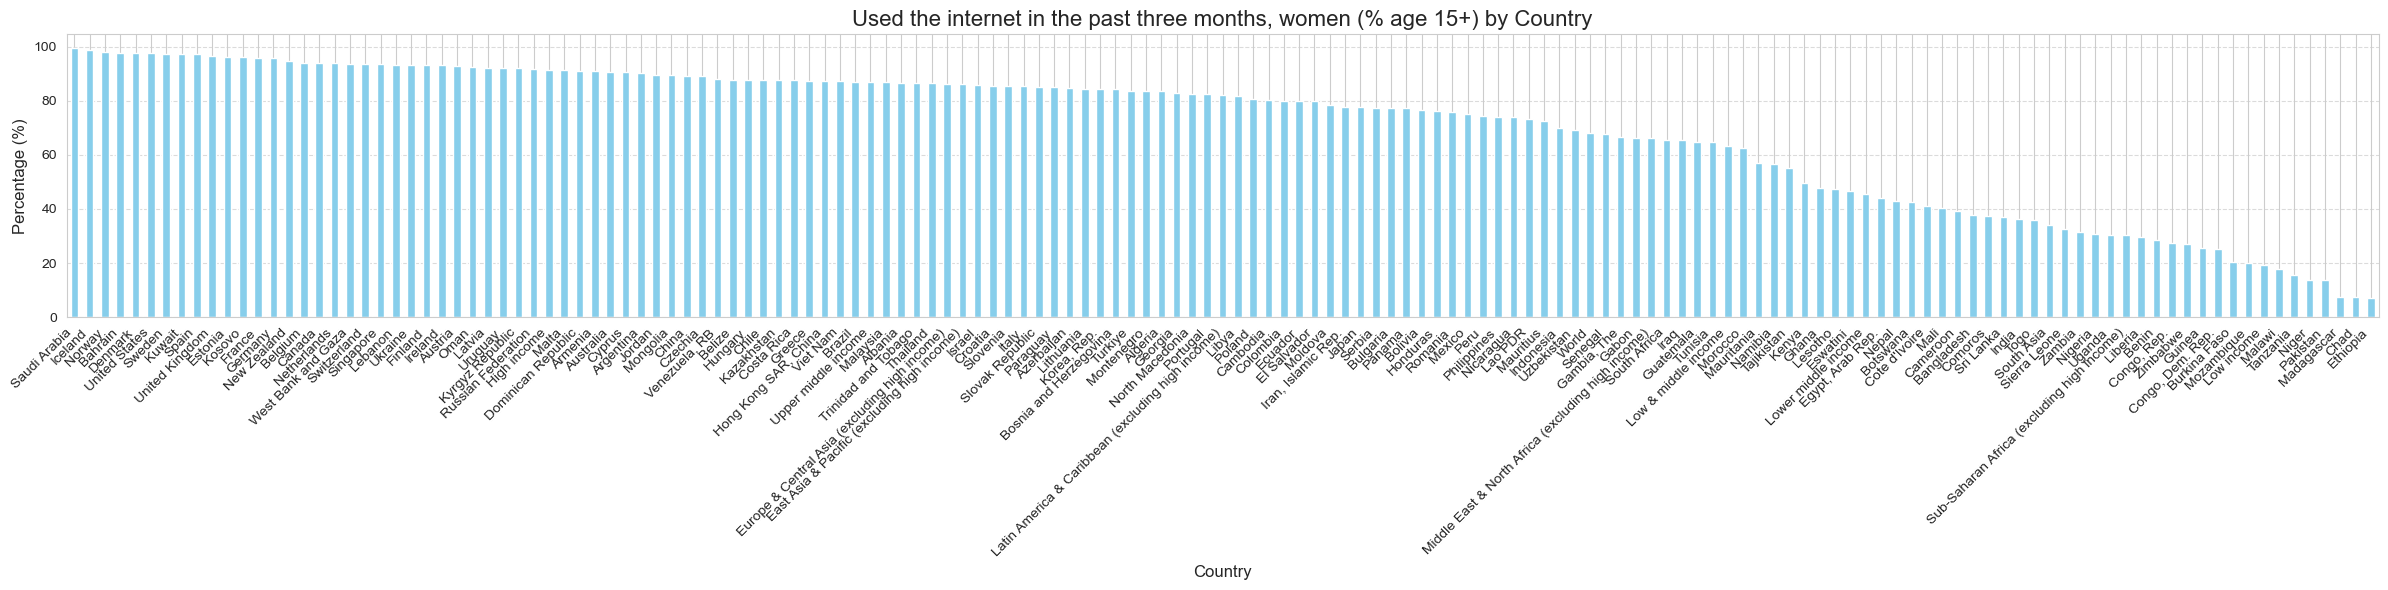

In [74]:

# List of indicators to plot
ict_indicators = [
    "Individuals using the Internet (% of population)",
    "Used the internet in the past three months, women (% age 15+)"
]

for indicator in ict_indicators:
    # Filter dataset for the current indicator
    df_ict = tech[tech["Indicator Name"] == indicator]
    
    # Pivot to have countries as index
    ict_pivot = df_ict.pivot_table(
        index="Country Name",
        values="Value",
        aggfunc="mean"
    ).sort_values(by="Value", ascending=False)
    
    # Plot bar chart
    plt.figure(figsize=(24, 6))
    ict_pivot['Value'].plot(kind='bar', color='skyblue')
    plt.title(f'{indicator} by Country', fontsize=16)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('Country', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [77]:
!pip install nbconvert[webpdf]


  Obtaining dependency information for pyppeteer<1.1,>=1 from https://files.pythonhosted.org/packages/10/46/33c0a9e7d37bf33487074de4399963462093043ad224d1881e41cbd937f3/pyppeteer-1.0.2-py3-none-any.whl.metadata
  Obtaining dependency information for pyee<9.0.0,>=8.1.0 from https://files.pythonhosted.org/packages/56/37/29d137df23ed1d88d8dcee8a6b8e789d1162042f194b5ccd0a48f503429b/pyee-8.2.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for websockets<11.0,>=10.0 from https://files.pythonhosted.org/packages/27/bb/6327e8c7d4dd7d5b450b409a461be278968ce05c54da13da581ac87661db/websockets-10.4-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/83.4 kB ? eta -:--:--
   ---------------------------------------- 83.4/83.4 kB 4.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/101.4 kB ? eta -:--:--
   ---------------------------------------- 101.4/101.4 kB 6.1 MB/s eta 0:00:00


In [78]:
%pip install "nbconvert[webpdf]"


Note: you may need to restart the kernel to use updated packages.
